### Load Modules

In [1]:
import os
import sys
from pathlib import Path

sys.path.append(str(Path(os.getcwd()).resolve()))

from tqdm import tqdm
from torchsummary import summary

import torch
import torch.optim as optim
import torch.nn as nn

from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import StepLR

import wandb
from torchsummary import summary

### Mount to Google drive

In [2]:
from google.colab import drive, userdata

if not os.path.exists('/content/drive'):
    drive.mount('/content/drive', force_remount=True)
    print("Drive mounted successfully!")
else:
    print("Drive already mounted.")

Drive already mounted.


### Clone git and load modules

In [3]:
!git clone https://github.com/gimoonnam/vgg16_practice.git

fatal: destination path 'vgg16_practice' already exists and is not an empty directory.


In [4]:
repo_path = '/content/vgg16_practice'
if repo_path not in sys.path:
  sys.path.insert(0, repo_path)

from src.load_data import split_dataset
from models.vgg16 import VGG16
from src.data_classes import TrainingConfig

In [5]:
data_path = r'/content/drive/My Drive/Data for Colab Training'

# CIFAR10 dataset
from torchvision import datasets, transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

# Load from already downloaded dataset (set download=False)
# CIFAR-10 will be in data_path/cifar-10-batches-py/
dataset_train = datasets.CIFAR10(root=data_path, train=True, download=False, transform=transform)
dataset_test = datasets.CIFAR10(root=data_path, train=False, download=False, transform=transform)

print(f"Training samples: {len(dataset_train)}")
print(f"Test samples: {len(dataset_test)}")

Training samples: 50000
Test samples: 10000


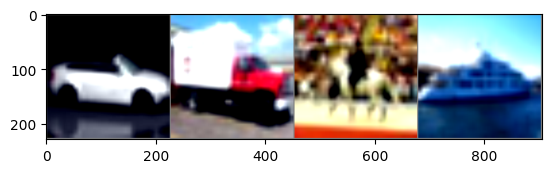

car   truck horse ship 


In [6]:
import numpy as np
import matplotlib.pyplot as plt

import torchvision
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

trainloader = DataLoader(dataset_train, batch_size=4, shuffle=True)

# 학습용 이미지를 무작위로 가져오기
dataiter = iter(trainloader)
images, labels = next(dataiter)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


# 이미지 보여주기
imshow(torchvision.utils.make_grid(images))
# 정답(label) 출력
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))


In [7]:
train_dataset, val_dataset = split_dataset(dataset_train, train_ratio=0.8)

# Configuration for training
config = TrainingConfig(
    batch_size=128,
    num_epochs=10,
    num_train_samples=len(train_dataset),  # Set from your dataset
    lr_scheduler_epoch=20,
    learning_rate=0.001,
    weight_decay=1e-4,
    save_path=r"/Users/gimoon/Documents/GitHub/vgg16_practice/checkpoints"
)
# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=False)

print(f"\nTrain batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

Training set size: 40000
Validation set size: 10000

Train batches: 313
Validation batches: 79


In [8]:
dataset_train[0][0].std()

tensor(0.7386)

### Load VGG16 model

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = VGG16(3, len(classes)).to(device)

print(device)

summary(model, (3, 224, 224))


cuda
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 224, 224]           1,792
              ReLU-2         [-1, 64, 224, 224]               0
            Conv2d-3         [-1, 64, 224, 224]          36,928
              ReLU-4         [-1, 64, 224, 224]               0
         MaxPool2d-5         [-1, 64, 112, 112]               0
            N_conv-6         [-1, 64, 112, 112]               0
            Conv2d-7        [-1, 128, 112, 112]          73,856
              ReLU-8        [-1, 128, 112, 112]               0
            Conv2d-9        [-1, 128, 112, 112]         147,584
             ReLU-10        [-1, 128, 112, 112]               0
        MaxPool2d-11          [-1, 128, 56, 56]               0
           N_conv-12          [-1, 128, 56, 56]               0
           Conv2d-13          [-1, 256, 56, 56]         295,168
             ReLU-14          [-1,

In [10]:
lr_scheduler_step_size = config.lr_scheduler_step_size()
print(lr_scheduler_step_size)

total_steps = config.total_steps()
print(total_steps)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=config.learning_rate, weight_decay=config.weight_decay)
scheduler = StepLR(optimizer, step_size=config.lr_scheduler_epoch, gamma=0.5)

6240
3120


In [11]:
from datetime import datetime
import pytz

asia_tz = pytz.timezone("Asia/Seoul")
saved_time = datetime.now(asia_tz).strftime("%Y-%m-%d %H:%M:%S")
run_name = f"checkpoint_CIFAR10_batchSize{config.batch_size}_nEpoch{config.num_epochs}_lr{config.learning_rate}_weightDecay1e-4_{saved_time}"
print(run_name)

checkpoint_CIFAR10_batchSize128_nEpoch10_lr0.001_weightDecay1e-4_2026-02-17 14:19:24


### Configuring WandB

In [12]:
os.environ["WANDB_API_KEY"] = userdata.get('wandb_key')
wandb.login()

# Start a new wandb run to track this script.
run = wandb.init(
    # Set the wandb entity where your project will be logged (generally your team name).
    entity="gimoonnam",
    # Set the wandb project where this run will be logged.
    project="vgg16_practice",
    # Track hyperparameters and,
    name = run_name,

    config={
        "learning_rate": config.learning_rate,
        "architecture": "CNN",
        "dataset": "CIFAR-10",
        "epochs": config.num_epochs,
    },
)




wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: gimoonnam to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


### Training along with validating

In [13]:
curr_lr = scheduler.get_last_lr()[0]

for epoch in range(config.num_epochs):
    # ==================== TRAINING ====================
    model.train()
    epoch_train_loss = 0.0

    ProgressBar = tqdm(enumerate(train_loader), total=len(train_loader))

    for batch_idx, (inputs, labels) in ProgressBar:
        # Ensure labels are torch.long before moving to device for CrossEntropyLoss
        inputs, labels = inputs.to(device), labels.to(device)
        labels = labels.long()

        optimizer.zero_grad()
        logits = model(inputs)

        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()

        # Update Progress bar (only training loss during training)
        ProgressBar.set_description(f'Epoch [{epoch+1}/{config.num_epochs}]')
        ProgressBar.set_postfix(TrainLoss=loss.item(), lr=curr_lr)

    # Average training loss for the epoch
    avg_train_loss = epoch_train_loss / len(train_loader)


    # ==================== VALIDATION (Once per epoch) ====================
    model.eval()
    val_loss = 0.0
    num_correct = 0
    num_samples = 0

    print(f"\nRunning validation for epoch {epoch+1}...")
    with torch.no_grad():
        for inputs_val, labels_val in tqdm(val_loader, desc="Validating"):
            inputs_val, labels_val = inputs_val.to(device), labels_val.to(device)
            logits_val = model(inputs_val)
            loss_val = criterion(logits_val, labels_val)
            val_loss += loss_val.item()
            _, predictions = logits_val.max(1)
            num_correct += (predictions == labels_val).sum()
            num_samples += predictions.size(0)

    avg_val_loss = val_loss / len(val_loader)
    avg_val_acc = (num_correct / num_samples).item()

    # Print epoch summary
    print(f"\nEpoch {epoch+1} Summary:")
    print(f"  Train Loss: {avg_train_loss:.4f}")
    print(f"  Val Loss:   {avg_val_loss:.4f}")
    print(f"  Val Acc:    {avg_val_acc:.4f}")

    # Update learning rate scheduler
    scheduler.step()
    curr_lr = scheduler.get_last_lr()[0]

    # Log metrics to wandb (once per epoch)
    run.log({
        "train_loss": avg_train_loss,
        "val_loss": avg_val_loss,
        "val_accuracy": avg_val_acc,
        "lr": curr_lr
    })

run.finish()


Epoch [1/10]: 100%|██████████| 313/313 [01:23<00:00,  3.75it/s, TrainLoss=1.73, lr=0.001]



Running validation for epoch 1...


Validating: 100%|██████████| 79/79 [00:09<00:00,  8.41it/s]



Epoch 1 Summary:
  Train Loss: 2.5250
  Val Loss:   1.7835
  Val Acc:    0.3231


Epoch [2/10]: 100%|██████████| 313/313 [01:22<00:00,  3.81it/s, TrainLoss=1.66, lr=0.001]


...

Epoch [10/10]: 100%|██████████| 313/313 [01:22<00:00,  3.77it/s, TrainLoss=0.804, lr=0.001]



Running validation for epoch 10...


Validating: 100%|██████████| 79/79 [00:09<00:00,  8.41it/s]


Epoch 10 Summary:
  Train Loss: 0.4742
  Val Loss:   0.8051
  Val Acc:    0.7309


lr,▁▁▁▁▁▁▁▁▁▁
train_loss,█▅▄▄▃▂▂▂▁▁
val_accuracy,▁▃▄▅▇▇████
val_loss,█▆▅▄▂▁▁▁▁▁
lr,0.001
train_loss,0.47424
val_accuracy,0.7309
val_loss,0.80514


In [14]:
# from models.vgg16 import save_checkpoint, load_checkpoint

checkpoint_path = r'/content/drive/My Drive/checkpoints'

checkpoint = {
    "batch_size": config.batch_size,
    "epoch": epoch,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    #"saved_datetime": current_time,
}

save_pth = os.path.join(checkpoint_path, f"{run_name}.pth.tar")
torch.save(checkpoint, save_pth)

# pth_file_path = os.path.join(checkpoint_path, 'checkpoint-2026-02-12 09_10_08.pth')
# model, optimizer, epoch, loss = load_checkpoint(pth_file_path, model, optimizer)

In [18]:
test_loader = DataLoader(dataset_test, batch_size=config.batch_size, shuffle=False)


In [29]:

@torch.no_grad()  # Disable gradient tracking for efficiency
def calc_accuracy_loader(data_loader, model, device, num_batches=None, desc='testing'):
    model.eval()
    correct_predictions, num_examples = 0, 0

    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))

    for i, (input_batch, target_batch) in enumerate(tqdm(data_loader, desc)):
        if i < num_batches:
            input_batch, target_batch = input_batch.to(device), target_batch.to(device)
            logits = model(input_batch)
            predicted_labels = torch.argmax(logits, dim=1)
            num_examples += predicted_labels.shape[0]
            correct_predictions += (predicted_labels == target_batch).sum().item()
        else:
            break
    return correct_predictions / num_examples

In [30]:
calc_accuracy_loader(test_loader, model, device, config.batch_size )

testing: 100%|██████████| 79/79 [00:09<00:00,  8.35it/s]


0.7338